In [50]:
import pandas as pd
from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# 1. fetch dataset from uci machine learning repository 

In [51]:
# fetch dataset fromu uci machine learning repositor by id
bank_marketing = fetch_ucirepo(id=222) 

# convert data (as pandas dataframes) 
X = bank_marketing.data.features 
y = bank_marketing.data.targets 
  

In [52]:
#display the first few rows of a dataset to check its working
print(X.head())

   age           job  marital  education default  balance housing loan  \
0   58    management  married   tertiary      no     2143     yes   no   
1   44    technician   single  secondary      no       29     yes   no   
2   33  entrepreneur  married  secondary      no        2     yes  yes   
3   47   blue-collar  married        NaN      no     1506     yes   no   
4   33           NaN   single        NaN      no        1      no   no   

  contact  day_of_week month  duration  campaign  pdays  previous poutcome  
0     NaN            5   may       261         1     -1         0      NaN  
1     NaN            5   may       151         1     -1         0      NaN  
2     NaN            5   may        76         1     -1         0      NaN  
3     NaN            5   may        92         1     -1         0      NaN  
4     NaN            5   may       198         1     -1         0      NaN  


# 2. Visualization

Text(0.5, 1.0, 'Age vs Subscription')

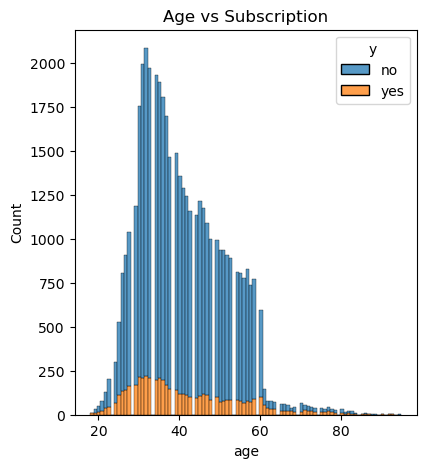

In [53]:
plt.figure(figsize=(15, 5))

# Age Distribution
plt.subplot(1, 3, 1)
sns.histplot(data=df, x='age', hue='y', multiple="stack")
plt.title('Age vs Subscription')


Text(0.5, 1.0, 'Job vs Subscription')

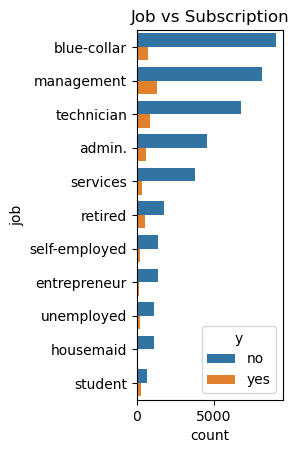

In [54]:
# Job Type
plt.subplot(1, 3, 2)
sns.countplot(data=df, y='job', hue='y', order=df['job'].value_counts().index)
plt.title('Job vs Subscription')

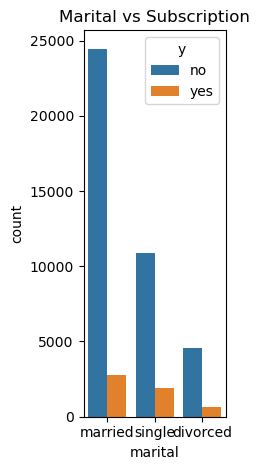

In [55]:
# Marital Status
plt.subplot(1, 3, 3)
sns.countplot(data=df, x='marital', hue='y')
plt.title('Marital vs Subscription')

plt.tight_layout()
plt.show()

# 3. Encode categorical features

In [56]:
X_encoded = pd.get_dummies(X, columns=['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome'], drop_first=True)

# 4. Convert target 'y' to binary (0 and 1)

In [57]:
y_numeric = y['y'].map({'yes': 1, 'no': 0})

# 5. Split data (80% training, 20% testing)


In [58]:
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y_numeric, test_size=0.2, random_state=42)

# 6. Train Decision Tree classifier Machine Model.


In [64]:

dt_model = DecisionTreeClassifier(max_depth=5, random_state=42) # Max depth prevents overfitting
dt_model.fit(X_train, y_train)

print("Decision Tree Performance:")
print(classification_report(y_test, dt_model.predict(X_test)))

Decision Tree Performance:
              precision    recall  f1-score   support

           0       0.91      0.98      0.94      7952
           1       0.65      0.33      0.44      1091

    accuracy                           0.90      9043
   macro avg       0.78      0.65      0.69      9043
weighted avg       0.88      0.90      0.88      9043



# 7.Business insight extraction from data

In [60]:
# 1. Train Decision Tree (limiting depth to 5 for easy interpretation)
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)

# 2. Extract Feature Importances
importances = dt_model.feature_importances_
feature_names = X_encoded.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# 3. Print Top 5 Insights
print("Top 5 Decision Drivers:")
print(feature_importance_df.head(5))

Top 5 Decision Drivers:
             Feature  Importance
3           duration    0.574335
37  poutcome_success    0.301786
0                age    0.052928
31         month_mar    0.040052
22       housing_yes    0.009591


In [67]:
# 1. Get the probability of 'Yes' (Class 1) for every customer
# [:, 1] extracts the probability of being a 'Yes'
y_probs = dt_model.predict_proba(X_test)[:, 1]

# 2. Create a summary table of the Top 10 most likely customers
results = pd.DataFrame({
    'Actual_Outcome': y_test.values,
    'Probability_of_Accepting': y_probs
})

# 3. Sort by the highest probability
high_value_leads = results.sort_values(by='Probability_of_Accepting', ascending=False)

print("Top 10 Customers Most Likely to Accept:")
print(high_value_leads.head(10))

Top 10 Customers Most Likely to Accept:
      Actual_Outcome  Probability_of_Accepting
5137               0                  1.000000
8390               1                  0.928571
5820               1                  0.928571
3409               1                  0.928571
6283               1                  0.928571
8862               1                  0.928571
721                1                  0.928571
1810               1                  0.928571
5303               1                  0.928571
8970               1                  0.928571
